# Surrogate Impact on Quantum Circuit Synthesis with Evolutionary Algorithms

## Set up Dependencies

In [1]:
import json
import numpy as np
import os
from pprint import pprint
import scipy
from statistics import mean, stdev
from typing import List, Dict, Callable

In [2]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100 # TODO: Change DPI before submitting paper.

In [3]:
import pandas as pd

## Util Functions

In [4]:
def load_json(path: str) -> Dict:
    with open(path, "r") as json_file:
        return json.load(json_file)

In [5]:
def printb(text: str) -> None:
    print("\033[1m" + text + "\033[0m")

In [6]:
from dataclasses import dataclass


@dataclass
class Experiment:
    model: str
    qubit_num: int
    gate_count: int

    parent_count: int
    offspring_count: int
    max_generations: int

    source_paths: List[str]
    seeds: List[int]

    tag: str
    data_per_seed: List[pd.DataFrame]
    data_by_generation: pd.DataFrame
    data_by_timestamp: pd.DataFrame

    def __hash__(self) -> str:
        key = f"{self.qubit_num}_{self.gate_count}_{self.model}_"
        key += f"{self.parent_count}_{self.offspring_count}_"
        key += f"{self.max_generations}_"
        # key += f"{self.tag}t"
        return hash(key)

    def __eq__(self, value: "Experiment"):
        return self.__hash__() == value.__hash__()

    @property
    def config(self):
        return {
            "model": self.model,
            "qubit_num": self.qubit_num,
            "gate_count": self.gate_count,
            "parent_count": self.parent_count,
            "offspring_count": self.offspring_count,
            "max_generations": self.max_generations,
            "tag": self.tag,
            "seeds": sorted(self.seeds)
        }

In [7]:
def filter_experiments(experiments: List[Experiment], filter_params: Dict, sort_by: str = "qubit_num") -> List[Experiment]:

    filtered_experiments: List[Experiment] = []
    for experiment in experiments:

        for key, value in filter_params.items():
            
            if experiment.config[key] != value:
                break 

        else:
            filtered_experiments.append(experiment)                 


    filtered_experiments.sort(key=lambda item: item.config[sort_by])
    return filtered_experiments

In [8]:
def sort_by_model(experiments: List[Experiment]) -> None:
    no_model_index = [
        experiment.model for experiment in experiments].index(None)
    no_model_experiment = experiments.pop(no_model_index)

    experiments.sort(key=lambda experiment: experiment.model)
    experiments.insert(0, no_model_experiment)

In [9]:
def load_experiments(results_dir: str = "results", min_generations: int = None) -> List[Experiment]:
    experiments: Dict[str, Experiment] = {}

    for file_name in os.listdir(results_dir):
        if not file_name.endswith("_config.json"):
            continue

        config_path = f"{results_dir}/{file_name}"
        config = load_json(config_path)

        logging_prefix: str = config["params"]["logging_prefix"]

        data_path = logging_prefix + "_results.csv"

        experiment_data = pd.read_csv(data_path, delimiter=";")
        for column in experiment_data.columns:
            experiment_data = experiment_data.rename(columns={
                column: column.strip().replace(" ", "_")
            })
        enhance_data(experiment_data)

        experiment = Experiment(
            model=config["params"]["surrogate"]["type"] if "type" in config["params"]["surrogate"] else None,
            qubit_num=config["params"]["ea"]["qubit_num"],
            gate_count=config["params"]["ea"]["gate_count"],

            parent_count=config["params"]["ea"]["parent_count"],
            offspring_count=config["params"]["ea"]["offspring_count"],
            max_generations=config["params"]["ea"]["max_generations"],

            tag=config["params"]["tag"],

            source_paths=[
                config_path
            ],

            seeds=[
                config["params"]["seed"]
            ],

            data_per_seed=[experiment_data],
            data_by_generation=None,
            data_by_timestamp=None,
        )

        if experiment in experiments and experiment.seeds[0] in experiments[experiment].seeds:
            print(
                f"Excluding data of {experiment.source_paths[0]} due to seed duplication.")
            
        elif experiment in experiments:
            experiments[experiment].source_paths.append(
                experiment.source_paths[0])
            experiments[experiment].seeds.append(experiment.seeds[0])
            experiments[experiment].data_per_seed.append(
                experiment.data_per_seed[0])
            
        else:
            experiments[experiment] = experiment

    experiments: List[Experiment] = list(experiments.values())
    for experiment in experiments:
        data_dfs = experiment.data_per_seed
        lengths = [len(df) for df in data_dfs]

        if min_generations is None:
            min_gen_threshold = max(lengths)
        else:
            min_gen_threshold = min_generations

        entries_to_pop = [
            i for i, length in enumerate(lengths) if length < min_gen_threshold
        ]

        for entry_to_pop in reversed(entries_to_pop):
            print(
                f"Excluding fitness of {experiment.source_paths[entry_to_pop]} due to length mismatch ({lengths[entry_to_pop]} vs. {min_gen_threshold}).")

            experiment.source_paths.pop(entry_to_pop)
            experiment.seeds.pop(entry_to_pop)
            experiment.data_per_seed.pop(entry_to_pop)

        experiment.data_by_generation = merge_by_generation(
            experiment.data_per_seed)
        experiment.data_by_timestamp = merge_by_timestamp(
            experiment.data_per_seed)

    return experiments

In [10]:
def enhance_data(df: pd.DataFrame):
    df["cum_duration"] = df["total_duration"].cumsum()

In [ ]:
def merge_by_generation(dfs: List[pd.DataFrame]) -> pd.DataFrame:
    total_df = pd.concat(dfs)

    # Parse columns that might have nan values
    total_df["fitness_mse"] = pd.to_numeric(total_df["fitness_mse"], errors="coerce")
    total_df["rank_correlation"] = pd.to_numeric(total_df["rank_correlation"], errors="coerce")

    grouped_fitness = total_df.groupby("generation")["fitness_best"]
    mean_best_fitness = grouped_fitness.mean()
    median_best_fitness = grouped_fitness.median()
    stdev_best_fitness = grouped_fitness.std()

    grouped_ea_duration = total_df.groupby("generation")["ea_duration"]
    mean_ea_duration = grouped_ea_duration.mean()
    median_ea_duration = grouped_ea_duration.median()
    stdev_ea_duration = grouped_ea_duration.std()

    grouped_eval_duration = total_df.groupby("generation")["eval_duration"]
    mean_eval_duration = grouped_eval_duration.mean()
    median_eval_duration = grouped_eval_duration.median()
    stdev_eval_duration = grouped_eval_duration.std()

    grouped_train_duration = total_df.groupby("generation")["train_duration"]
    mean_train_duration = grouped_train_duration.mean()
    median_train_duration = grouped_train_duration.median()
    stdev_train_duration = grouped_train_duration.std()

    grouped_pred_duration = total_df.groupby("generation")["pred_duration"]
    mean_pred_duration = grouped_pred_duration.mean()
    median_pred_duration = grouped_pred_duration.median()
    stdev_pred_duration = grouped_pred_duration.std()

    grouped_ea_memory = total_df.groupby("generation")["ea_memory"]
    mean_ea_memory = grouped_ea_memory.mean()
    median_ea_memory = grouped_ea_memory.median()
    stdev_ea_memory = grouped_ea_memory.std()

    grouped_eval_memory = total_df.groupby("generation")["eval_memory"]
    mean_eval_memory = grouped_eval_memory.mean()
    median_eval_memory = grouped_eval_memory.median()
    stdev_eval_memory = grouped_eval_memory.std()

    grouped_train_memory = total_df.groupby("generation")["train_memory"]
    mean_train_memory = grouped_train_memory.mean()
    median_train_memory = grouped_train_memory.median()
    stdev_train_memory = grouped_train_memory.std()

    grouped_pred_memory = total_df.groupby("generation")["pred_memory"]
    mean_pred_memory = grouped_pred_memory.mean()
    median_pred_memory = grouped_pred_memory.median()
    stdev_pred_memory = grouped_pred_memory.std()

    # TODO: Add max memory

    grouped_fitness_mse = total_df.groupby("generation")["fitness_mse"]
    mean_fitness_mse = grouped_fitness_mse.mean()
    median_fitness_mse = grouped_fitness_mse.median()
    stdev_fitness_mse = grouped_fitness_mse.std()

    grouped_rank_correlation = total_df.groupby("generation")["rank_correlation"]
    mean_rank_correlation = grouped_rank_correlation.mean()
    median_rank_correlation = grouped_rank_correlation.median()
    stdev_rank_correlation = grouped_rank_correlation.std()

    merged_df = pd.concat(
        [
            mean_best_fitness, median_best_fitness, stdev_best_fitness,
            mean_ea_duration, median_ea_duration, stdev_ea_duration,
            mean_eval_duration, median_eval_duration, stdev_eval_duration,
            mean_train_duration, median_train_duration, stdev_train_duration,
            mean_pred_duration, median_pred_duration, stdev_pred_duration,
            mean_ea_memory, median_ea_memory, stdev_ea_memory,
            mean_eval_memory, median_eval_memory, stdev_eval_memory,
            mean_train_memory, median_train_memory, stdev_train_memory, 
            mean_pred_memory, median_pred_memory, stdev_pred_memory,
            mean_fitness_mse, median_fitness_mse, stdev_fitness_mse,
            mean_rank_correlation, median_rank_correlation, stdev_rank_correlation
        ], keys=[
            "mean_best_fitness", "median_best_fitness", "stdev_best_fitness",
            "mean_ea_duration", "median_ea_duration", "stdev_ea_duration",
            "mean_eval_duration", "median_eval_duration", "stdev_eval_duration",
            "mean_train_duration", "median_train_duration", "stdev_train_duration",
            "mean_pred_duration", "median_pred_duration", "stdev_pred_duration",
            "mean_ea_memory", "median_ea_memory", "stdev_ea_memory",
            "mean_eval_memory", "median_eval_memory", "stdev_eval_memory",
            "mean_train_memory", "median_train_memory", "stdev_train_memory",
            "mean_pred_memory", "median_pred_memory", "stdev_pred_memory",
            "mean_fitness_mse", "median_fitness_mse", "stdev_fitness_mse",
            "mean_rank_correlation", "median_rank_correlation", "stdev_rank_correlation"
        ], axis=1
    )
    merged_df = merged_df.reset_index()
    # merged_df.fillna(0, inplace=True)

    return merged_df


In [12]:
def merge_by_timestamp(dfs: List[pd.DataFrame]) -> pd.DataFrame:

    # Create a copy for each df to avoid sideeffects based
    # on the upcoming in place modifications of these dfs.
    dfs = [df.copy() for df in dfs]

    unique_cum_durations = pd.concat(
        dfs)["cum_duration"].sort_values().unique()

    for i, df in enumerate(dfs):

        index = 0
        df_data = []

        min_cum_duration = df["cum_duration"].min()
        max_cum_duration = df["cum_duration"].max()

        for cum_duration in unique_cum_durations:

            if cum_duration < min_cum_duration:
                new_row = df.iloc[0].copy()
                new_row["cum_duration"] = cum_duration

                df_data.append(
                    new_row
                )

            elif cum_duration > max_cum_duration:
                new_row = df.iloc[-1].copy()
                new_row["cum_duration"] = cum_duration

                df_data.append(
                    new_row
                )

            else:

                if index + 1 < len(df) and df.iloc[index + 1]["cum_duration"] <= cum_duration:
                    index += 1

                new_row = df.iloc[index].copy()
                new_row["cum_duration"] = cum_duration

                df_data.append(
                    new_row
                )

        dfs[i] = pd.DataFrame(
            df_data, columns=df.columns
        )

    total_df = pd.concat(dfs)

    mean_best_fitness = total_df.groupby("cum_duration")["fitness_best"].mean()
    median_best_fitness = total_df.groupby(
        "cum_duration")["fitness_best"].median()
    stdev_best_fitness = total_df.groupby("cum_duration")["fitness_best"].std()

    merged_df = pd.concat(
        [mean_best_fitness, median_best_fitness, stdev_best_fitness], keys=["mean_best_fitness", "median_best_fitness", "stdev_best_fitness"], axis=1
    )
    merged_df = merged_df.reset_index()

    return merged_df

## Analysis Functions

In [13]:
def plot_fitness_per_generation(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        ax.plot(df["generation"], df["median_best_fitness"], label=label, linewidth=1)

        if plot_std:
            lower_bound = df["median_best_fitness"] - df["stdev_best_fitness"]
            upper_bound = df["median_best_fitness"] + df["stdev_best_fitness"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("best fitness")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()

In [14]:
def plot_fitness_per_timestamp(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_timestamp

        ax.plot(df["cum_duration"], df["median_best_fitness"], label=label, linewidth=1)

        if plot_std:
            lower_bound = df["median_best_fitness"] - df["stdev_best_fitness"]
            upper_bound = df["median_best_fitness"] + df["stdev_best_fitness"]
            ax.fill_between(
                df["cum_duration"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("time in sec.")

    ax.set_ylabel("best fitness")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()

## Fitness per Generation

In [15]:
experiments = load_experiments(
    results_dir="results/")

Excluding data of results//6qn20gcNonem0s_d2df0f4a-27e1-4a7b-aa81-230b6c98dee2_config.json due to seed duplication.
Excluding data of results//6qn20gcshot_distancem1s_5aca9086-0607-42ec-8f6f-a482d565a75e_config.json due to seed duplication.


ValueError: The length of the keys (32) must match the length of the objects to concatenate (33)

Experiment results for synthesis setup with 6 qubits and 10 gates.
Seed count per setup: 
[(None, 5), ('gate_frequency', 5), ('state_vector', 5)]
Fitness per generation


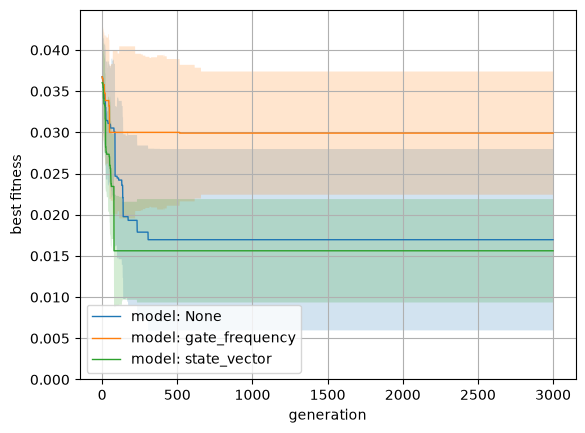

Fitness over time


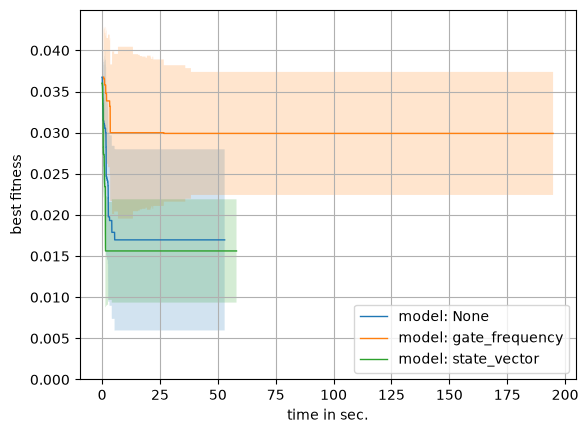

Experiment results for synthesis setup with 6 qubits and 20 gates.
Seed count per setup: 
[(None, 5), ('gate_frequency', 5), ('state_vector', 3)]
Fitness per generation


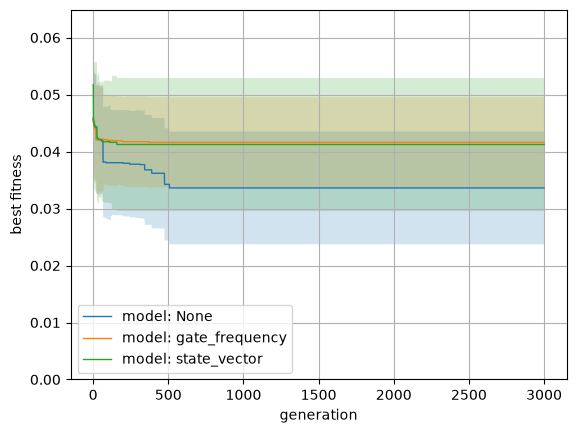

Fitness over time


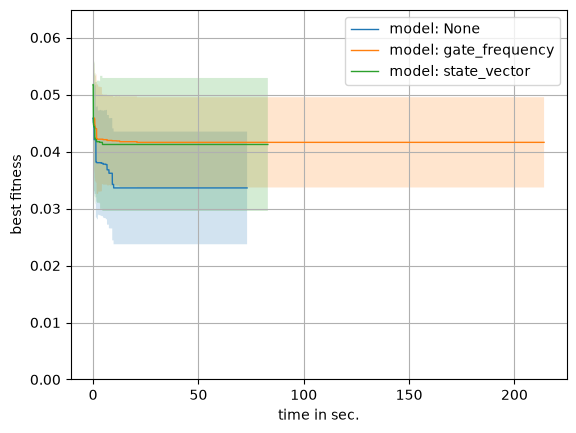

Experiment results for synthesis setup with 8 qubits and 20 gates.
Seed count per setup: 
[(None, 5), ('gate_frequency', 5), ('state_vector', 5)]
Fitness per generation


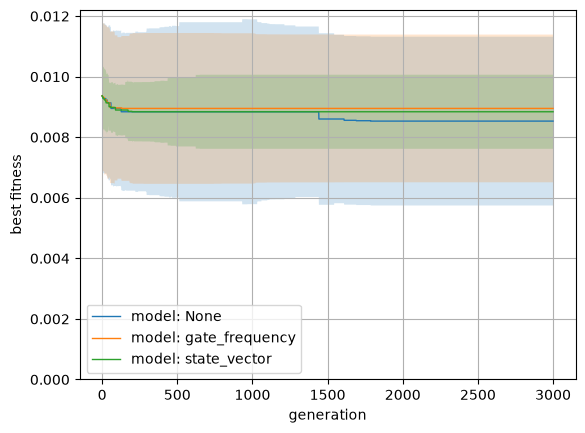

Fitness over time


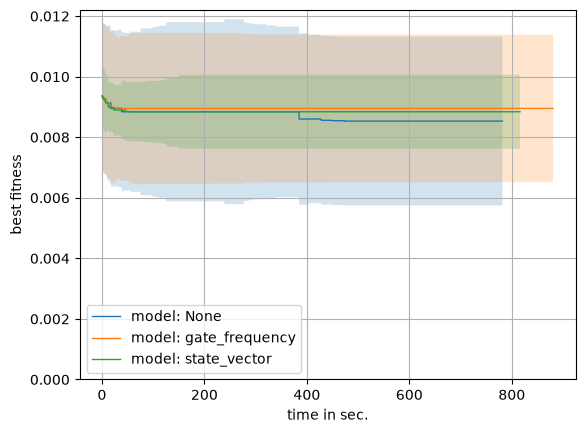

<Figure size 640x480 with 0 Axes>

In [ ]:
qubit_nums = [experiment.qubit_num for experiment in experiments]
qubit_nums = sorted(list(set(qubit_nums)))

gate_counts = [experiment.gate_count for experiment in experiments]
gate_counts = sorted(list(set(gate_counts)))

for qubit_num in qubit_nums:
    for gate_count in gate_counts:

        rel_experiments = filter_experiments(experiments, filter_params={
            "qubit_num": qubit_num,
            "gate_count": gate_count
        })

        if len(rel_experiments) == 0:
            continue

        sort_by_model(rel_experiments)

        printb(
            f"Experiment results for synthesis setup with {qubit_num} qubits and {gate_count} gates.")
        print("Seed count per setup: ")
        print([(experiment.model, len(experiment.seeds)) for experiment in rel_experiments])

        print("Fitness per generation")
        plot_fitness_per_generation(rel_experiments, labels=[
                                    f"model: {experiment.model}" for experiment in rel_experiments])

        print("Fitness over time")
        plot_fitness_per_timestamp(rel_experiments, labels=[
                                   f"model: {experiment.model}" for experiment in rel_experiments])